In [1]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/home/tjdu/micromamba/envs/solar-forecasting-hk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.plot import(
    plot_full_images_from_loader,plot_rmse_extremes_from_loader, plot_rmse_extremes_with_time_and_ghi
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.utils import crop_back, pad_to_32
from src.model_Twin import(TwinFiLMUNetTiny, TwinFiLMUNetTiny3L)

In [ ]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
)

print("Saved:", out)
print("Final shape:", shape)


Saved: Data/output/combined_hourly_with_elev_landmask_TEST.npz
Final shape: (7941, 12, 50, 50)


In [3]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (23625, 12, 50, 50)
y shape: (23625, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


In [4]:
import numpy as np

def compute_means(arr):
    # arr: (T,H,W) or (T,1,H,W)
    if arr.ndim == 4:
        arr = arr[:, 0]
    return arr.mean(axis=(1,2))

def make_labels(c0, c1, csi,
                tw_cs_thr=76.0,      # W/m^2 : twilight if clear-sky GHI below this
                clear_thr=0.80,      # CSI mean threshold for "clear"
                cloudy_thr=0.35):    # CSI mean threshold for "cloudy"
    """
    Returns labels:
      0=twilight, 1=clear, 2=cloudy, 3=mixed
    """
    c0m  = compute_means(c0)
    c1m  = compute_means(c1)
    csim = compute_means(csi)

    labels = np.full(len(c1m), 3, dtype=np.int64)  # default mixed

    tw = c1m < tw_cs_thr
    labels[tw] = 0

    daytime = ~tw
    labels[daytime & (csim >= clear_thr)] = 1
    labels[daytime & (csim <= cloudy_thr)] = 2

    return labels, {"c0_mean": c0m, "c1_mean": c1m, "csi_mean": csim}


In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_train_val_test_split(labels, train=0.7, val=0.15, test=0.15, seed=42):
    idx = np.arange(len(labels))

    idx_train, idx_tmp, y_train, y_tmp = train_test_split(
        idx, labels, test_size=(1-train), random_state=seed, stratify=labels
    )

    val_frac_of_tmp = val / (val + test)
    idx_val, idx_test, _, _ = train_test_split(
        idx_tmp, y_tmp, test_size=(1-val_frac_of_tmp),
        random_state=seed, stratify=y_tmp
    )
    return idx_train, idx_val, idx_test


In [6]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)

In [7]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_train_val_test_split(labels, 0.8, 0.1, 0.1, seed=42)

In [8]:
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

In [9]:
import numpy as np

y = y_test.reshape(-1)

for p in [1,5,50,95,99]:
    print(f"p{p}: {np.percentile(y, p):.4f}")

print("min:", y.min(), "max:", y.max())


p1: 0.0623
p5: 0.1075
p50: 0.8140
p95: 1.0000
p99: 1.0000
min: 0.05479572 max: 1.0


channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [10]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_strat_stats_day_30mins.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)


channel_min: [187.04999 183.7     185.03    182.54    208.92    182.60999 181.82
 182.57999 185.31999  38.89      0.        0.     ]
channel_max: [258.57     268.59     272.9      307.63     279.04     311.07
 309.99     302.66998  281.1       40.579998 804.1716     1.      ]


In [11]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import kornia

criterion_reg  = nn.SmoothL1Loss(beta=0.03, reduction="none")  # note: reduction none
criterion_mse  = nn.MSELoss(reduction="none")
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")

def grad_mag(x):
    # x: (B,1,H,W)
    dx = x[..., :, 1:] - x[..., :, :-1]
    dy = x[..., 1:, :] - x[..., :-1, :]
    # pad back to (B,1,H,W)
    dx = F.pad(dx, (0,1,0,0))
    dy = F.pad(dy, (0,0,0,1))
    return torch.sqrt(dx*dx + dy*dy + 1e-12)

def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).reshape(1,1,3,3)
    lp = F.conv2d(pred, k, padding=1)
    lt = F.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

def combined_loss(y_pred, y_true,
                  w_reg=0.4, w_mse=0.5, w_grad=0.1, alpha=0.7, k_edge=2.0, w_min=0.05, w_max=5.0):
    """
    - regression terms are weighted to focus on:
      (a) non-saturated pixels via (1-y)^alpha
      (b) fragmented-cloud boundaries via edge magnitude of y_true
    - structure terms (ssim/grad/lap) remain global.
    """

    # --- weights ---
    base = (1.0 - y_true).clamp(0.0, 1.0).pow(alpha)  # (B,1,H,W)

    edge = grad_mag(y_true)
    edge_norm = edge / (edge.mean(dim=(2,3), keepdim=True) + 1e-12)
    w = base * (1.0 + k_edge * edge_norm)
    w = w.clamp(w_min, w_max).detach()  # detach: weights shouldn't backprop through y_true ops

    # --- weighted regression losses ---
    reg_map = criterion_reg(y_pred, y_true)  # (B,1,H,W)
    mse_map = criterion_mse(y_pred, y_true)  # (B,1,H,W)
    reg = (w * reg_map).mean()
    mse = (w * mse_map).mean()

    # --- structure losses ---
    g    = grad_loss(y_pred, y_true)
    

    return w_reg*reg + w_mse*mse + w_grad*g


In [13]:
np.mean(y_train == 1.0)

np.float64(0.26340186243386243)

In [14]:
! export CUDA_VISIBLE_DEVICES=0 

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)

In [16]:
# ...existing code...
import os, torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch.cuda.is_available:", torch.cuda.is_available())
print("visible GPU count:", torch.cuda.device_count())

# confirm model parameters device
print("model device:", next(model.parameters()).device)

# show per-GPU memory usage (should be nonzero on only one device)
for i in range(torch.cuda.device_count()):
    used = torch.cuda.memory_allocated(i) / 1024**2
    reserved = torch.cuda.memory_reserved(i) / 1024**2
    print(f"GPU {i}: allocated={used:.1f}MB reserved={reserved:.1f}MB")

# enforce single visible GPU
assert torch.cuda.device_count() == 1, f"Expected 1 visible GPU, got {torch.cuda.device_count()}"
# ...existing code...

CUDA_VISIBLE_DEVICES: None
torch.cuda.is_available: True
visible GPU count: 2


NameError: name 'model' is not defined

In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

model = TwinFiLMUNetTiny3L(feature_size=48).to(device)

# -----------------------------
# Optimizer + scheduler
# -----------------------------
total_epochs = 150
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_loader),
    epochs=total_epochs,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=5.0,        # initial lr = max_lr/div_factor
    final_div_factor=50.0  # final lr = initial_lr/final_div_factor
)

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(total_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss, device, scheduler)
    val_loss, val_rmse = evaluate(model, val_loader, combined_loss, device)
    print(f"Epoch {epoch+1:03d}/{total_epochs}: loss={train_loss:.6f} | val {val_loss:.4f} | rmse {val_rmse:.4f} | lr {optimizer.param_groups[0]['lr']}")

Epoch 001/150: loss=0.104257 | val 0.1018 | rmse 0.2983 | lr 0.00010437146241964123
Epoch 002/150: loss=0.090857 | val 0.0816 | rmse 0.2007 | lr 0.00011729475284170162
Epoch 003/150: loss=0.085468 | val 0.0790 | rmse 0.2116 | lr 0.00013820493448199966
Epoch 004/150: loss=0.085598 | val 0.0785 | rmse 0.2070 | lr 0.00016618792660825094
Epoch 005/150: loss=0.084950 | val 0.0742 | rmse 0.1790 | lr 0.00020002046323576537
Epoch 006/150: loss=0.080229 | val 0.0717 | rmse 0.1692 | lr 0.00023822356774025972
Epoch 007/150: loss=0.077476 | val 0.0714 | rmse 0.1607 | lr 0.00027912720576518375
Epoch 008/150: loss=0.077117 | val 0.0718 | rmse 0.1791 | lr 0.0003209432901460118
Epoch 009/150: loss=0.075217 | val 0.0845 | rmse 0.2193 | lr 0.0003618438464686705
Epoch 010/150: loss=0.073192 | val 0.0951 | rmse 0.1644 | lr 0.0004000409222840906
Epoch 011/150: loss=0.072447 | val 0.0746 | rmse 0.1921 | lr 0.00043386474677759924
Epoch 012/150: loss=0.071571 | val 0.0689 | rmse 0.1528 | lr 0.0004618367241725

In [ ]:
b = next(iter(train_loader))
print(type(b))
if isinstance(b, (list, tuple)):
    print("len:", len(b), "types:", [type(x) for x in b])
elif isinstance(b, dict):
    print("keys:", b.keys())


<class 'list'>
len: 2 types: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [33]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 1.014149
rRMSE: 1.446483
R2: -9.548437
MBE: -0.534077
MAE: 0.805686
mean_true: 0.701113


In [30]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

SyntaxError: invalid syntax (2549857000.py, line 1)

In [27]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"] # shape (T, 2, H, W)
time_mins = cams["time_min"]  # shape (T,)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)

ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


In [34]:
cams.keys()

KeysView(NpzFile 'Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz' with keys: data, time_min, time_dt64m)

swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

In [49]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.127353
CSI_rRMSE: 0.181644
CSI_R2: 0.833658
CSI_MBE: -0.025752
CSI_MAE: 0.088010
CSI_mean_true: 0.701113
GHI_RMSE: 17.641434
GHI_rRMSE: 0.173634
GHI_R2: 0.935187
GHI_MBE: -2.686665
GHI_MAE: 11.539084
GHI_mean_true: 101.601112


CSI_RMSE: 0.113492
CSI_rRMSE: 0.161874
CSI_R2: 0.867896
CSI_MBE: 0.001639
CSI_MAE: 0.069650
CSI_mean_true: 0.701113
GHI_RMSE: 15.273839
GHI_rRMSE: 0.150331
GHI_R2: 0.951417
GHI_MBE: 0.815047
GHI_MAE: 8.970662
GHI_mean_true: 101.601112

In [47]:
15.273839*4

61.095356

CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058

In [ ]:
# ckpt_path = "Model_checkpoint/ckpt_last2.pt"

# torch.save({
#     "epoch": epoch,                      # current epoch index (0-based)
#     "model": model.state_dict(),
#     "optimizer": optimizer.state_dict(),
#     "scheduler": scheduler.state_dict() if scheduler is not None else None,
# }, ckpt_path)


In [38]:
PATH = "Model_checkpoint/Swin+_elevation_no_twil_30mins_2lay.pth"
# torch.save(model.state_dict(), PATH)

In [39]:
import torch
import torch.nn.functional as F

model = TwinFiLMUNetTiny3L(feature_size=48).to(device)

# 1) load checkpoint
model.load_state_dict(torch.load(PATH))
model.to(device)


TwinFiLMUNetTiny3L(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (c2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 48, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
  )
  (film): FiLM(
    (gamma): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    (beta): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (down): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), pad

In [45]:
ghi_cs_test.shape

(2363, 1, 50, 50)

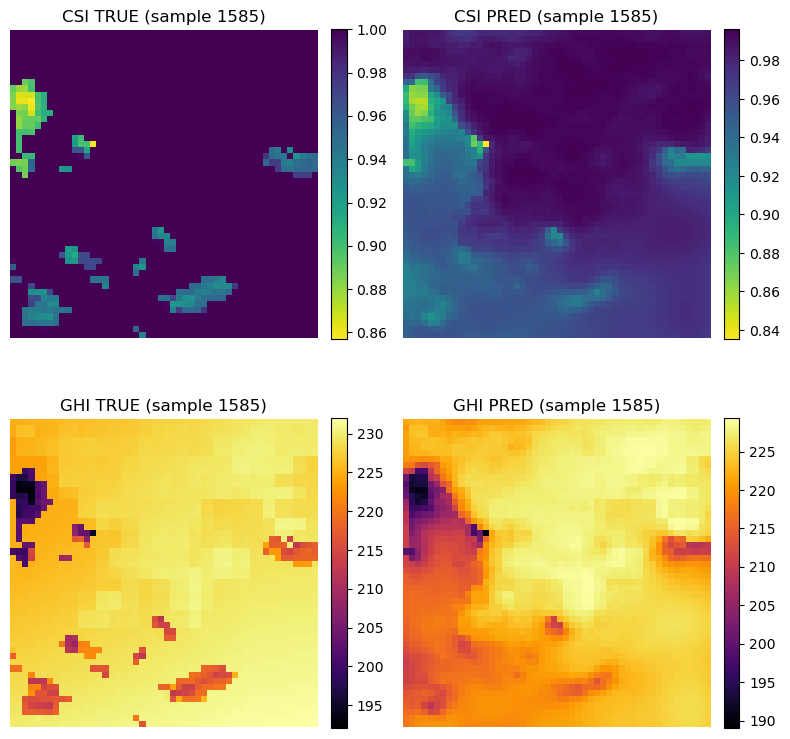

In [48]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=1,
    seed=5
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [43]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"] # shape (T, 2, H, W)
time_mins = cams["time_min"] 

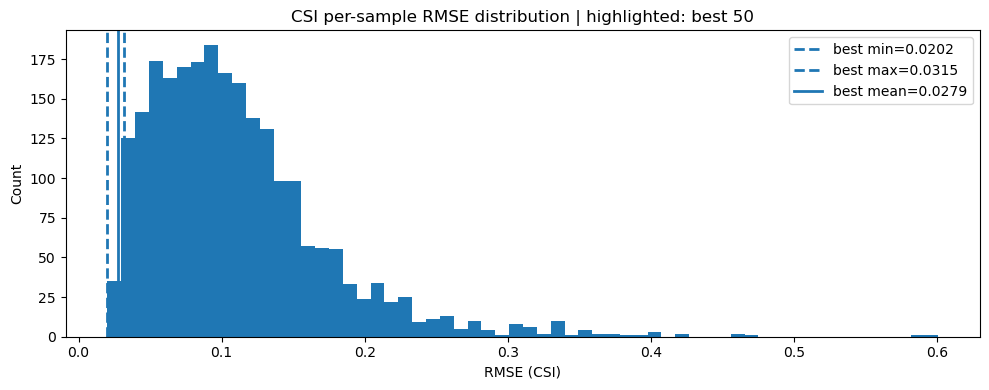

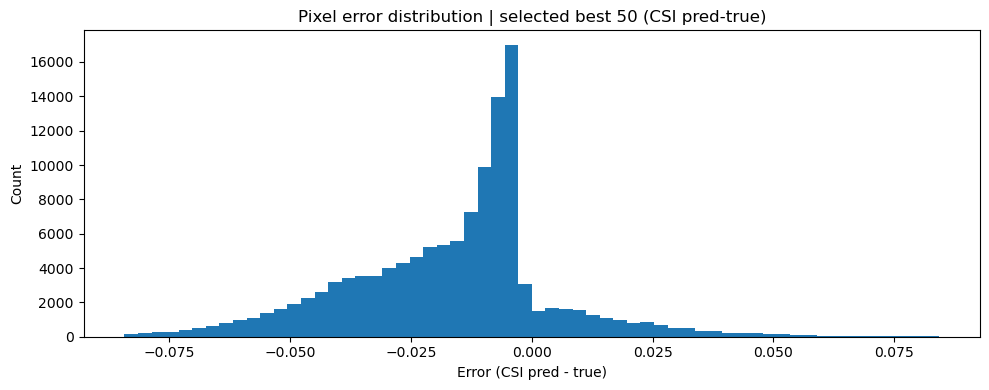

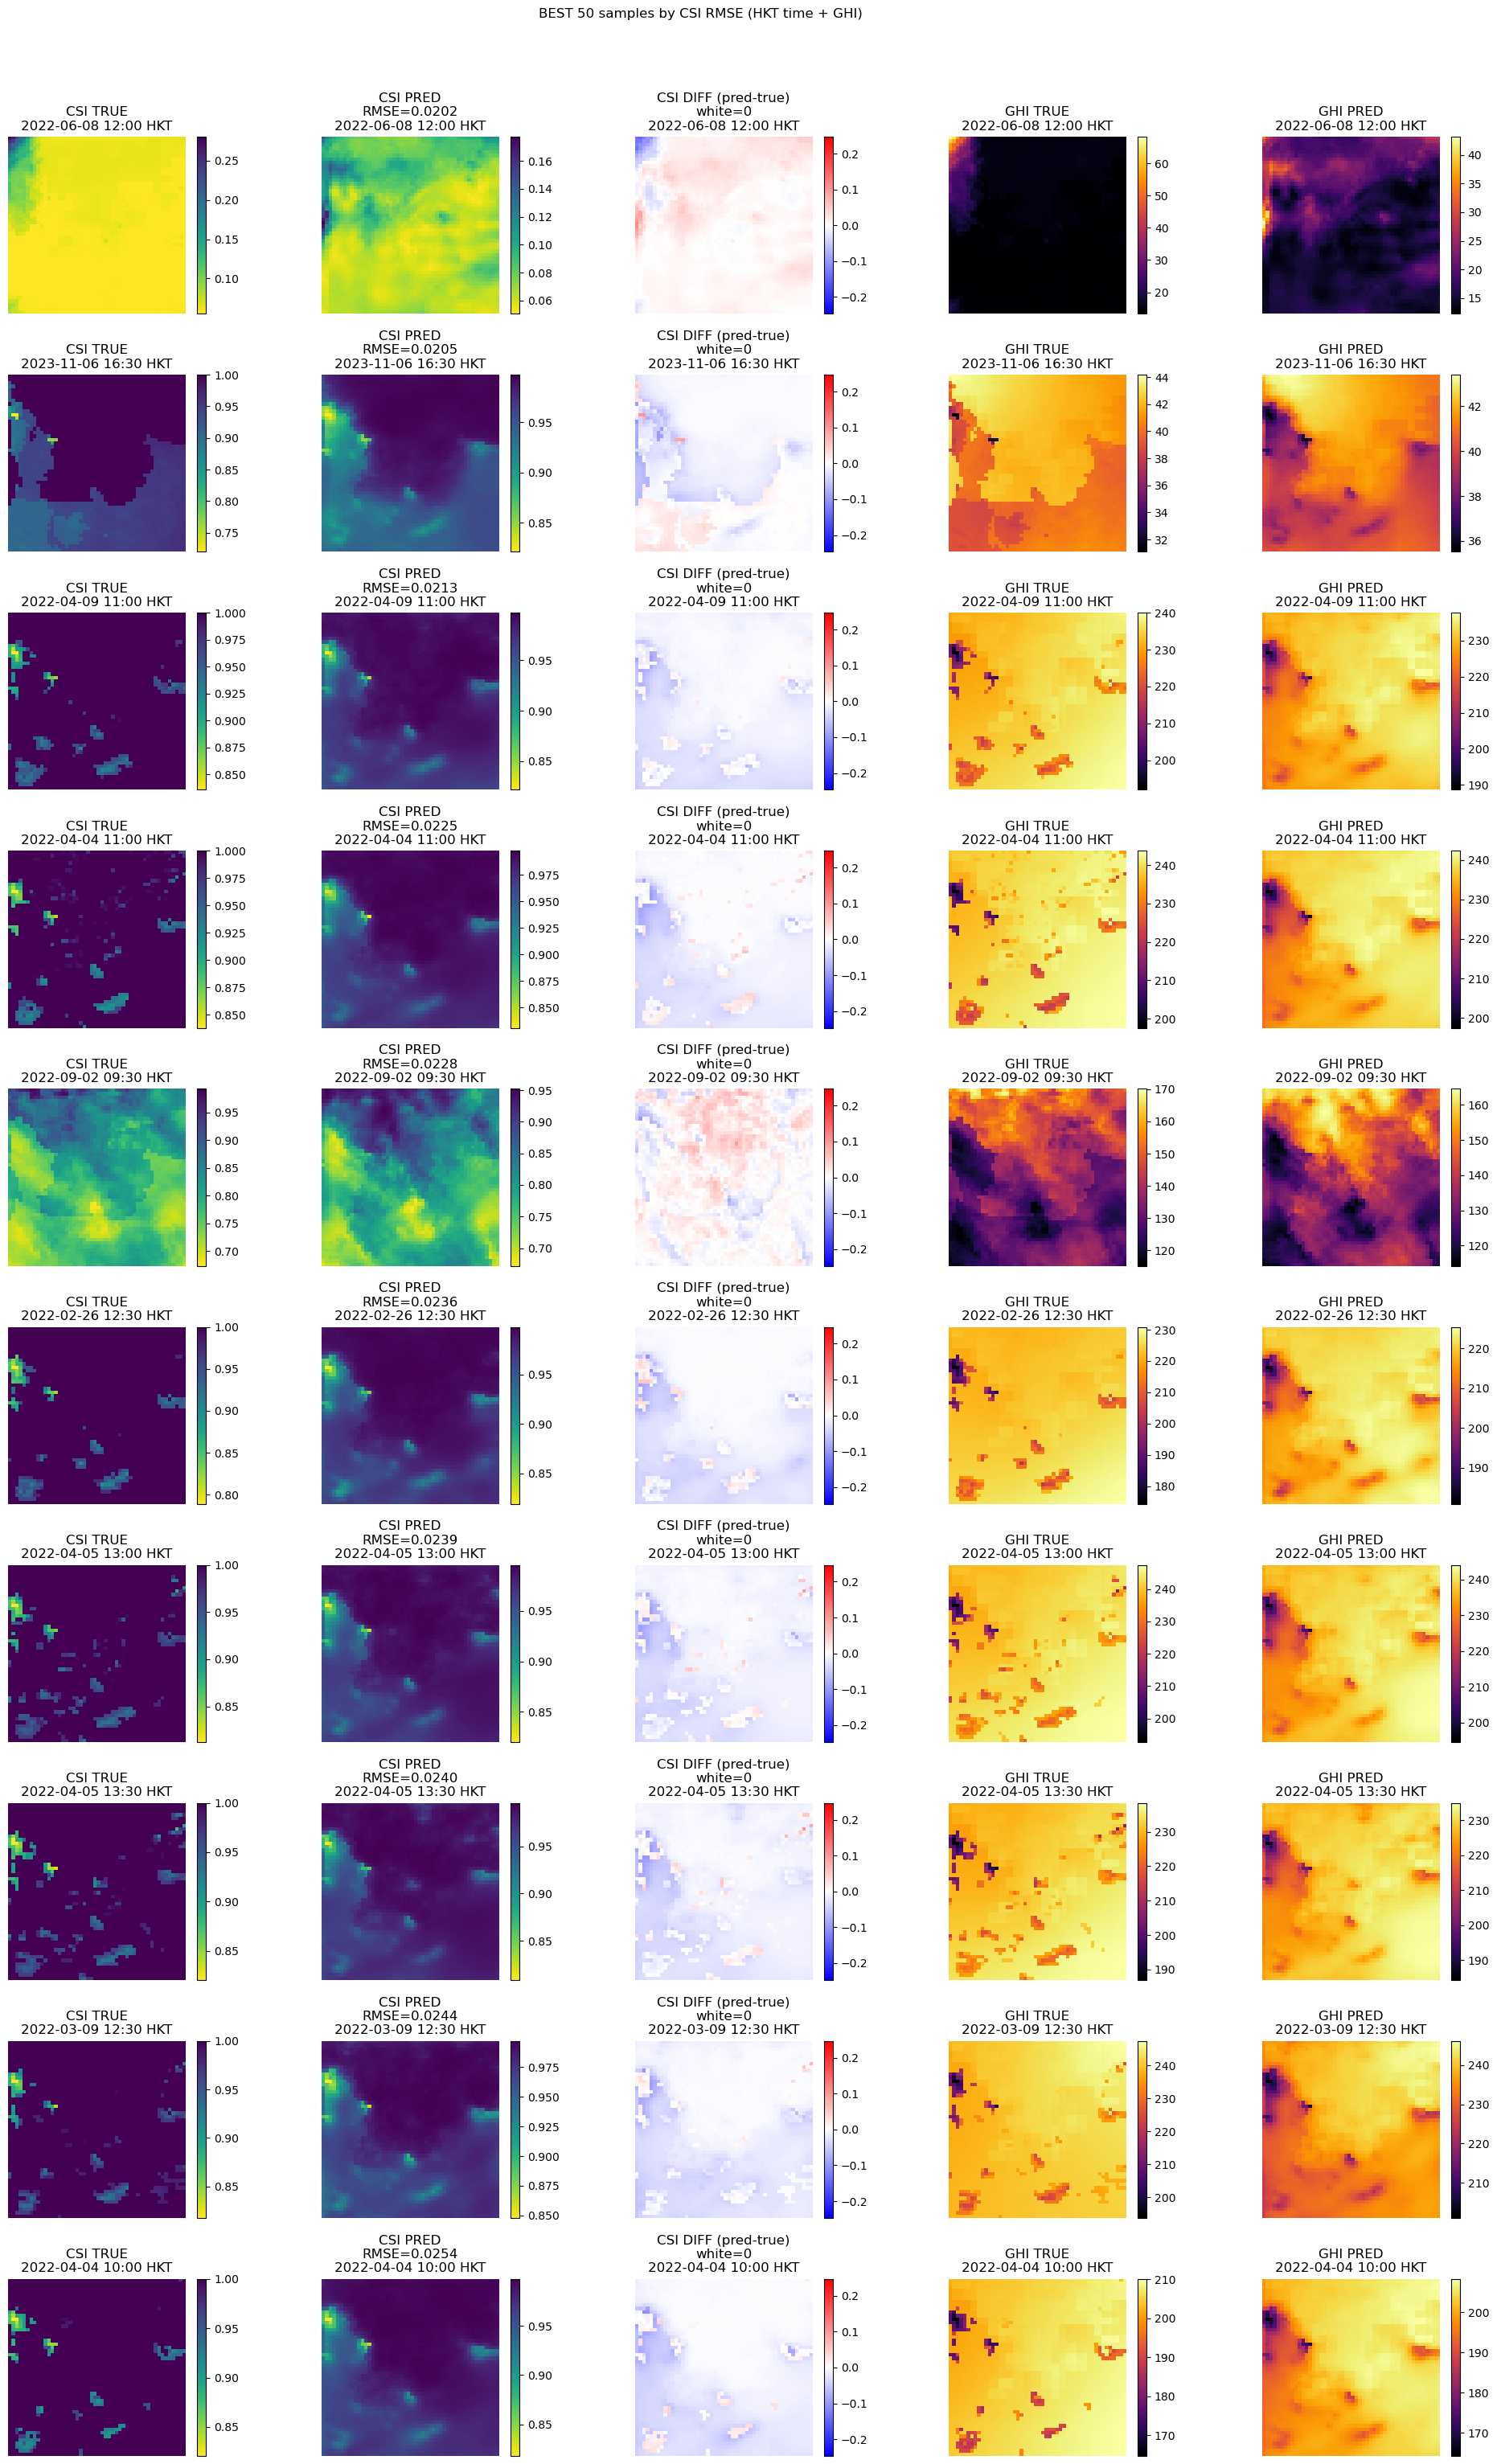

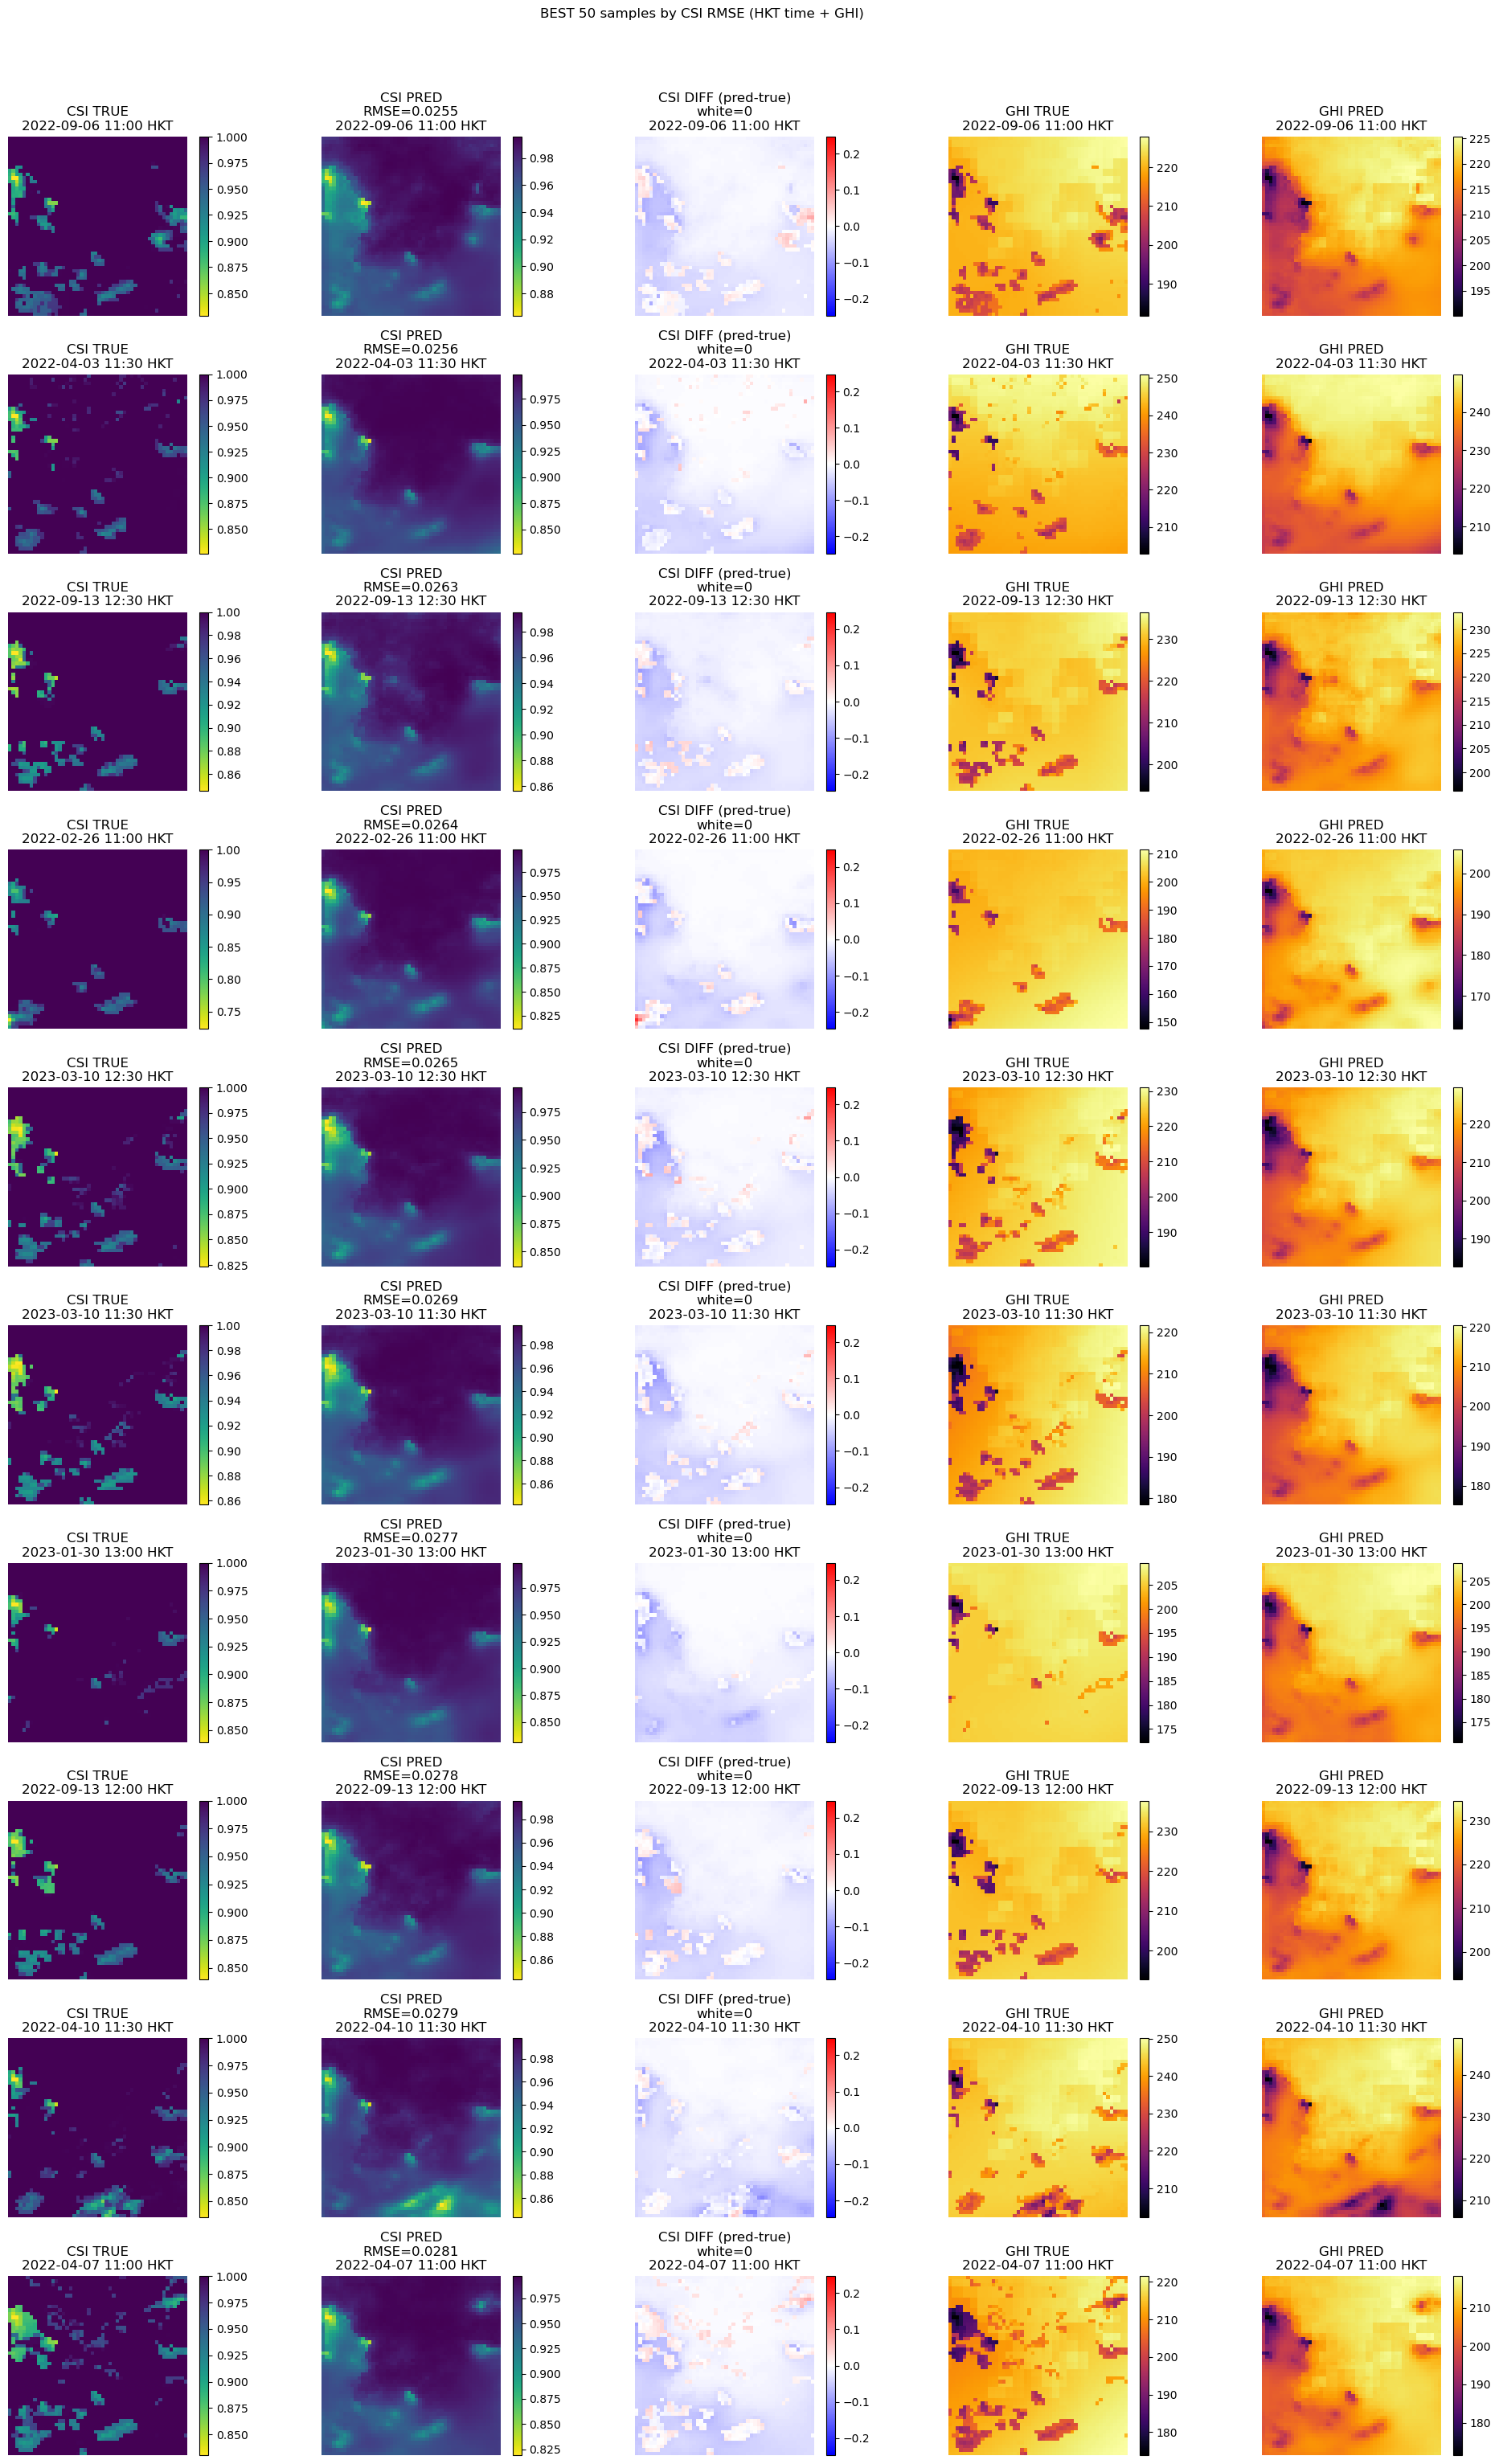

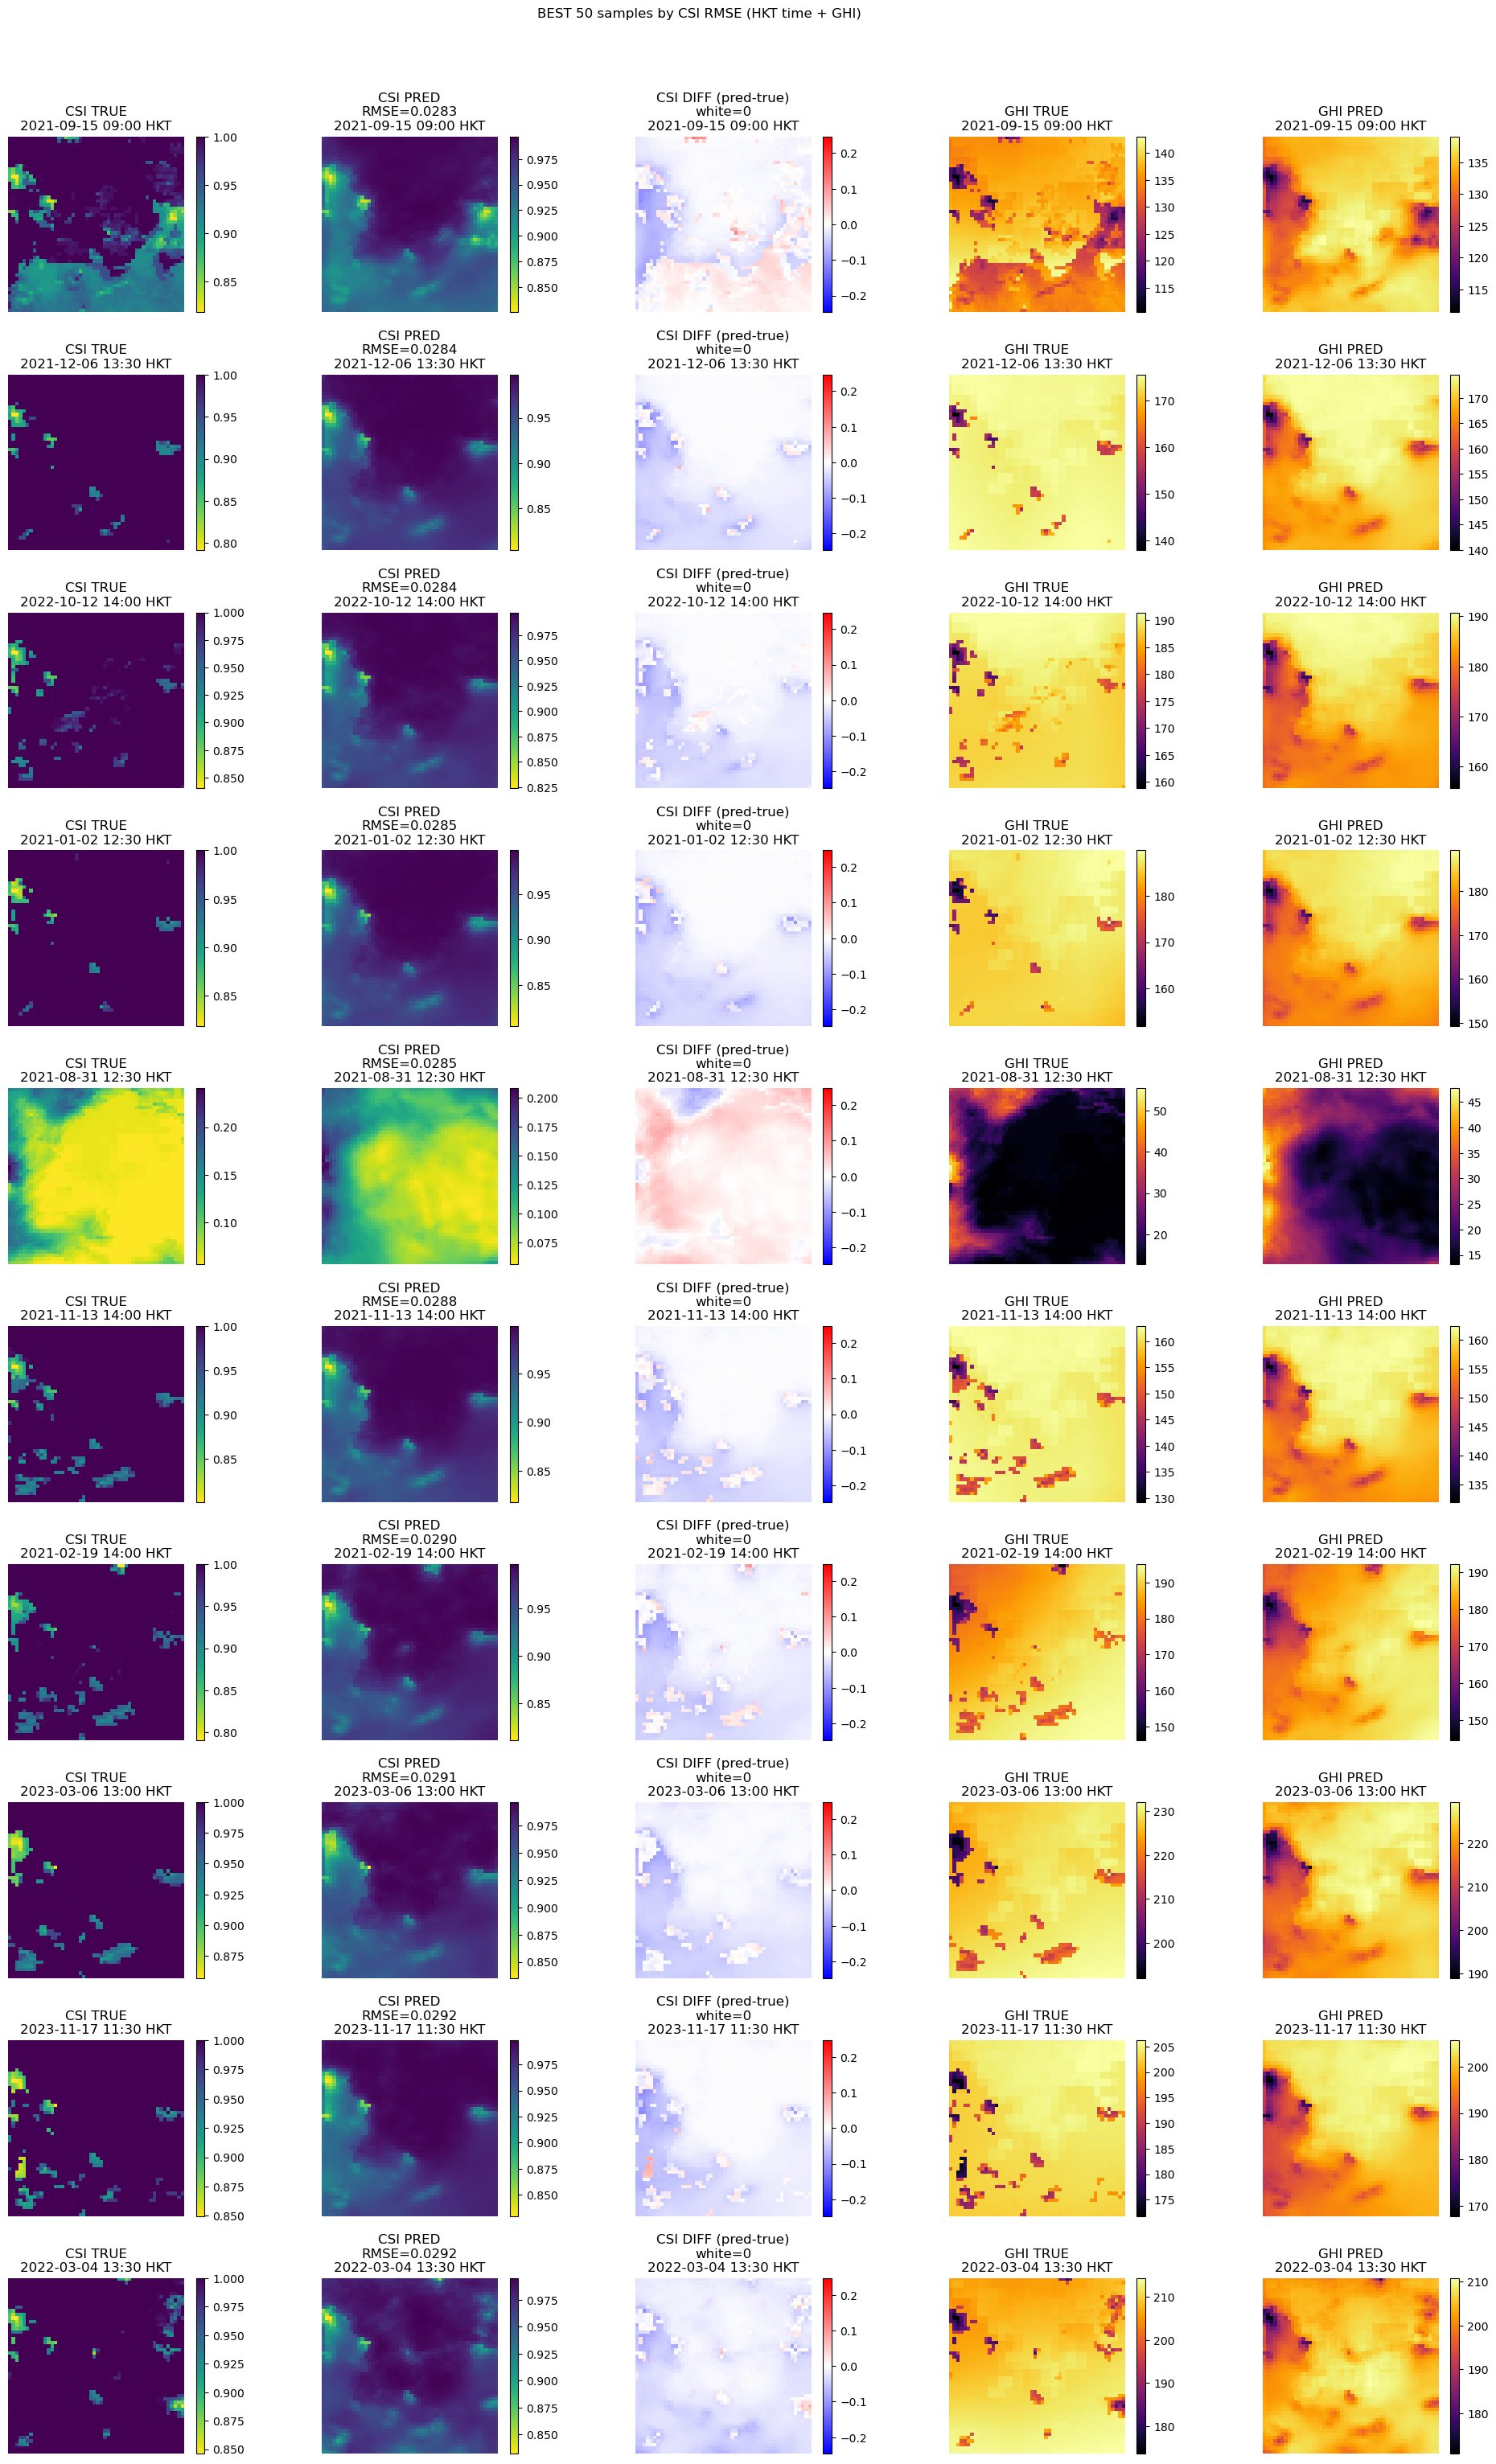

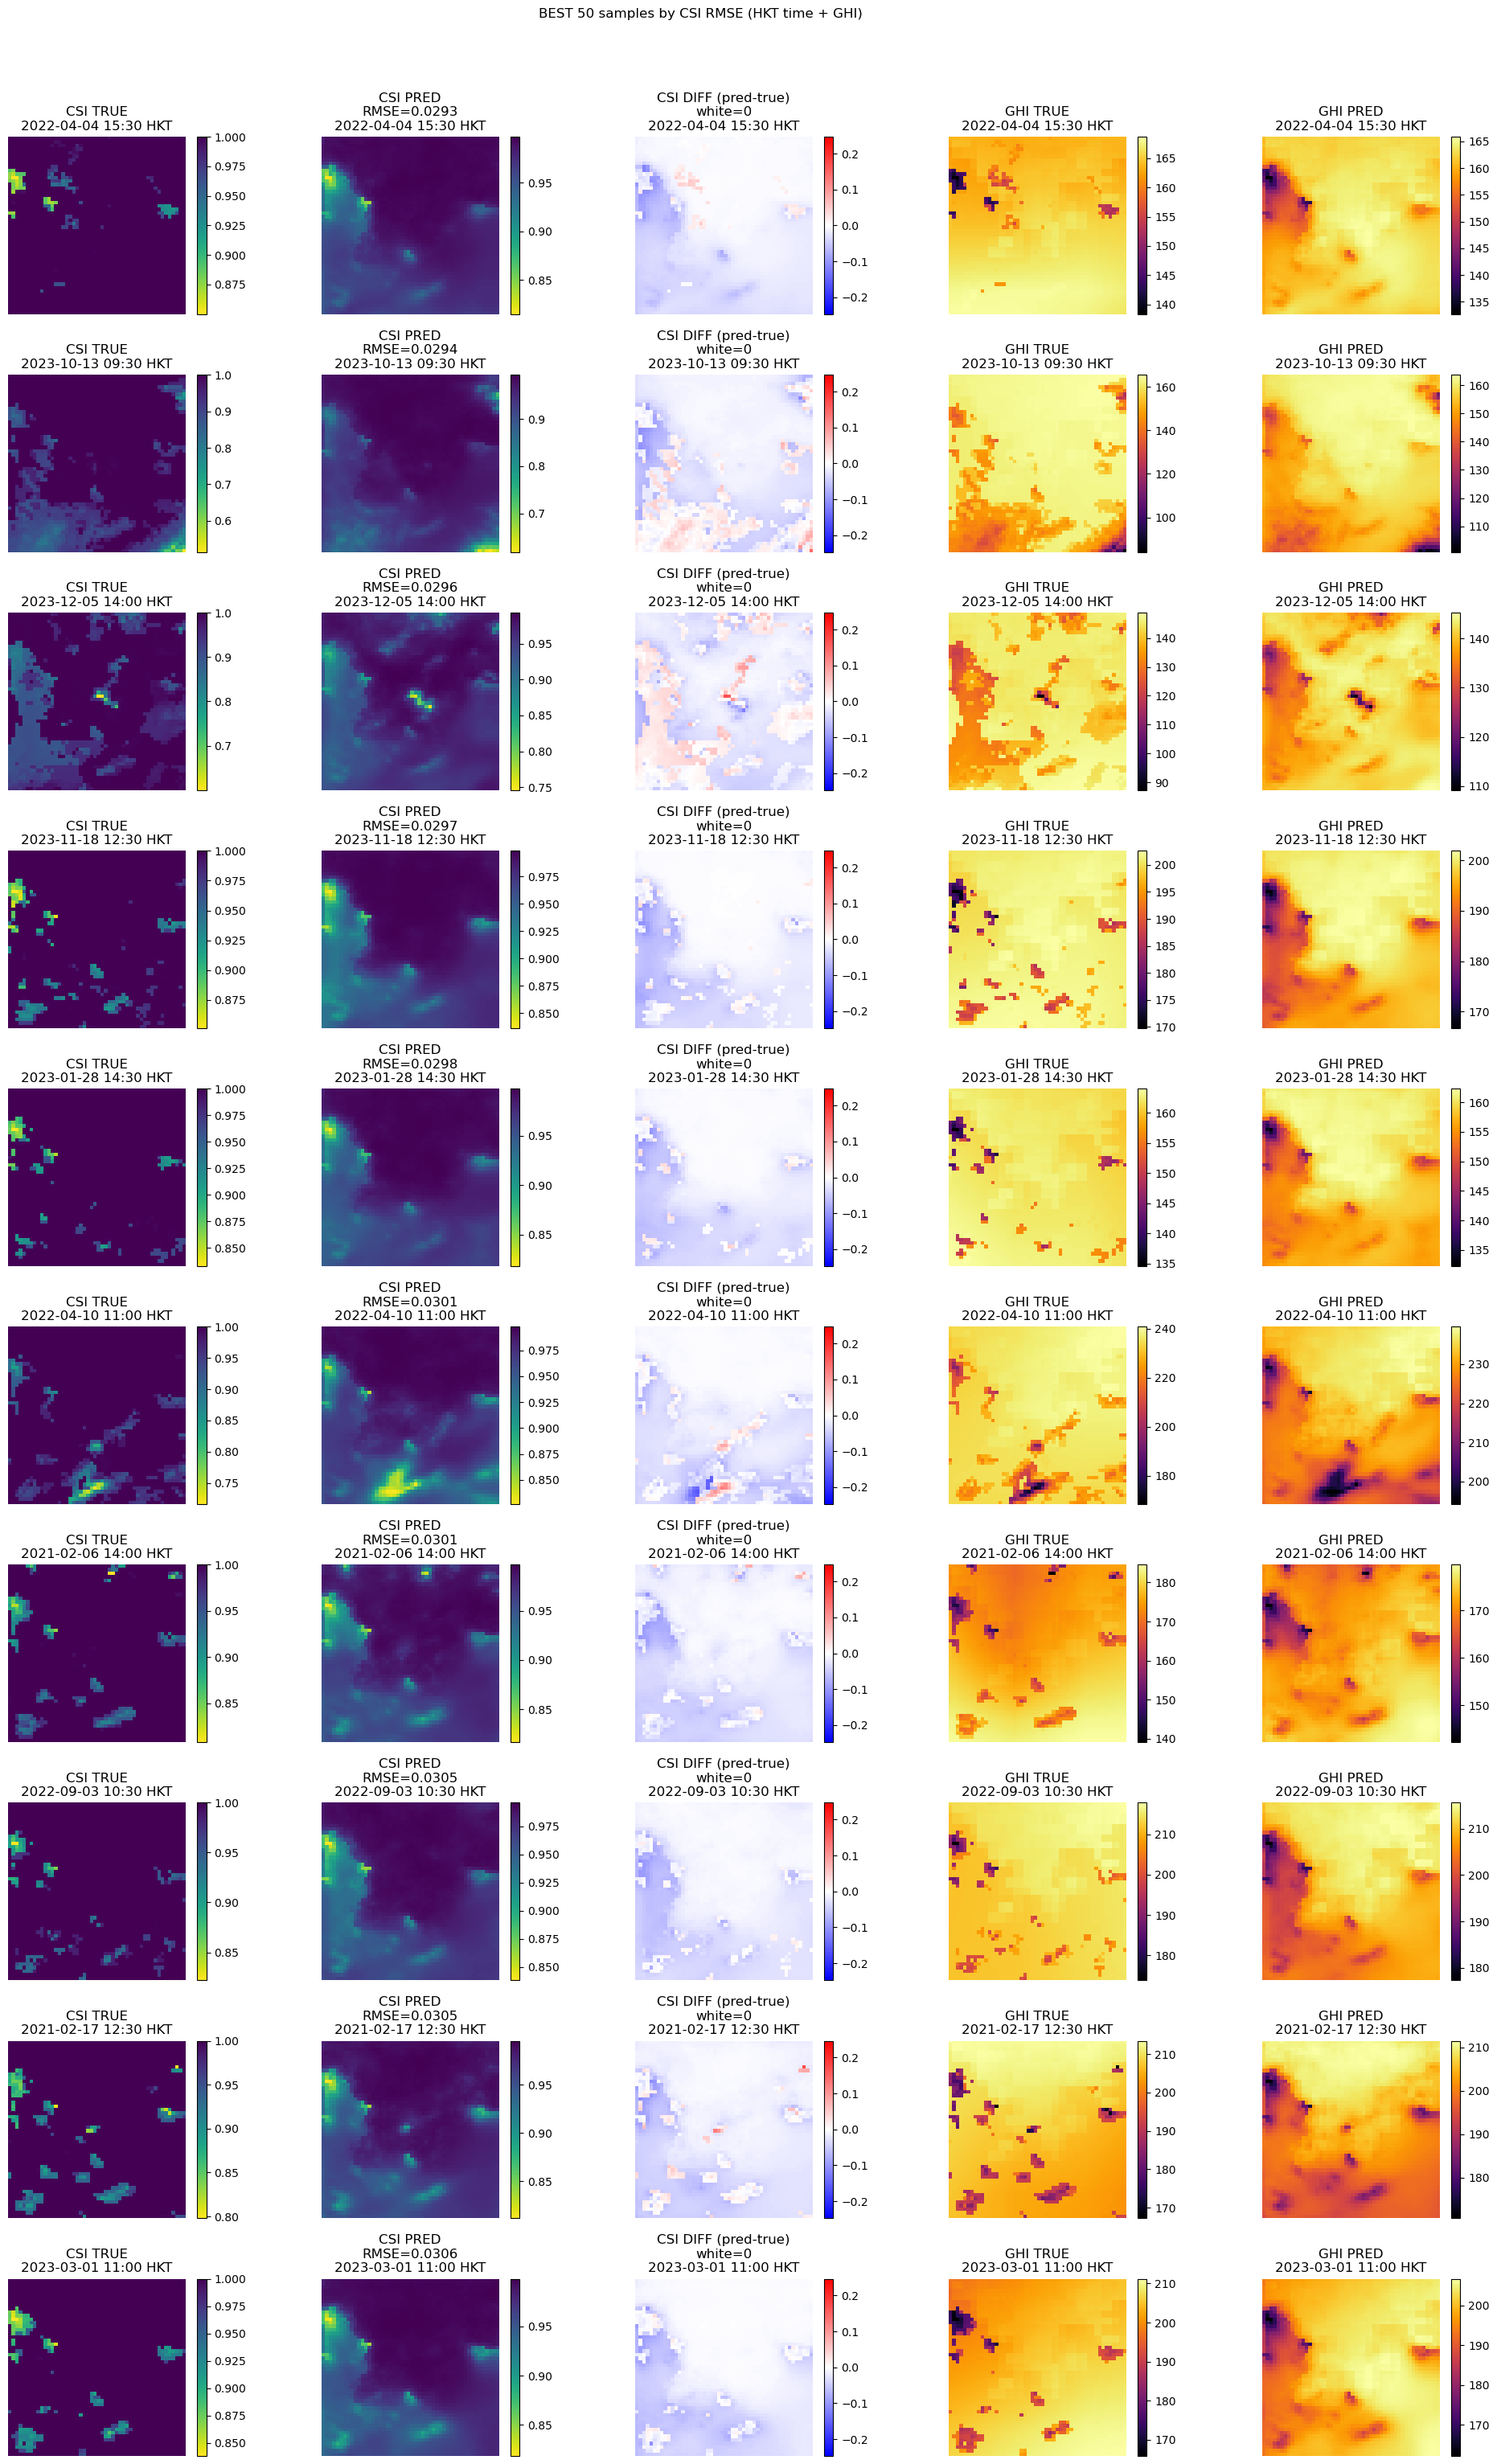

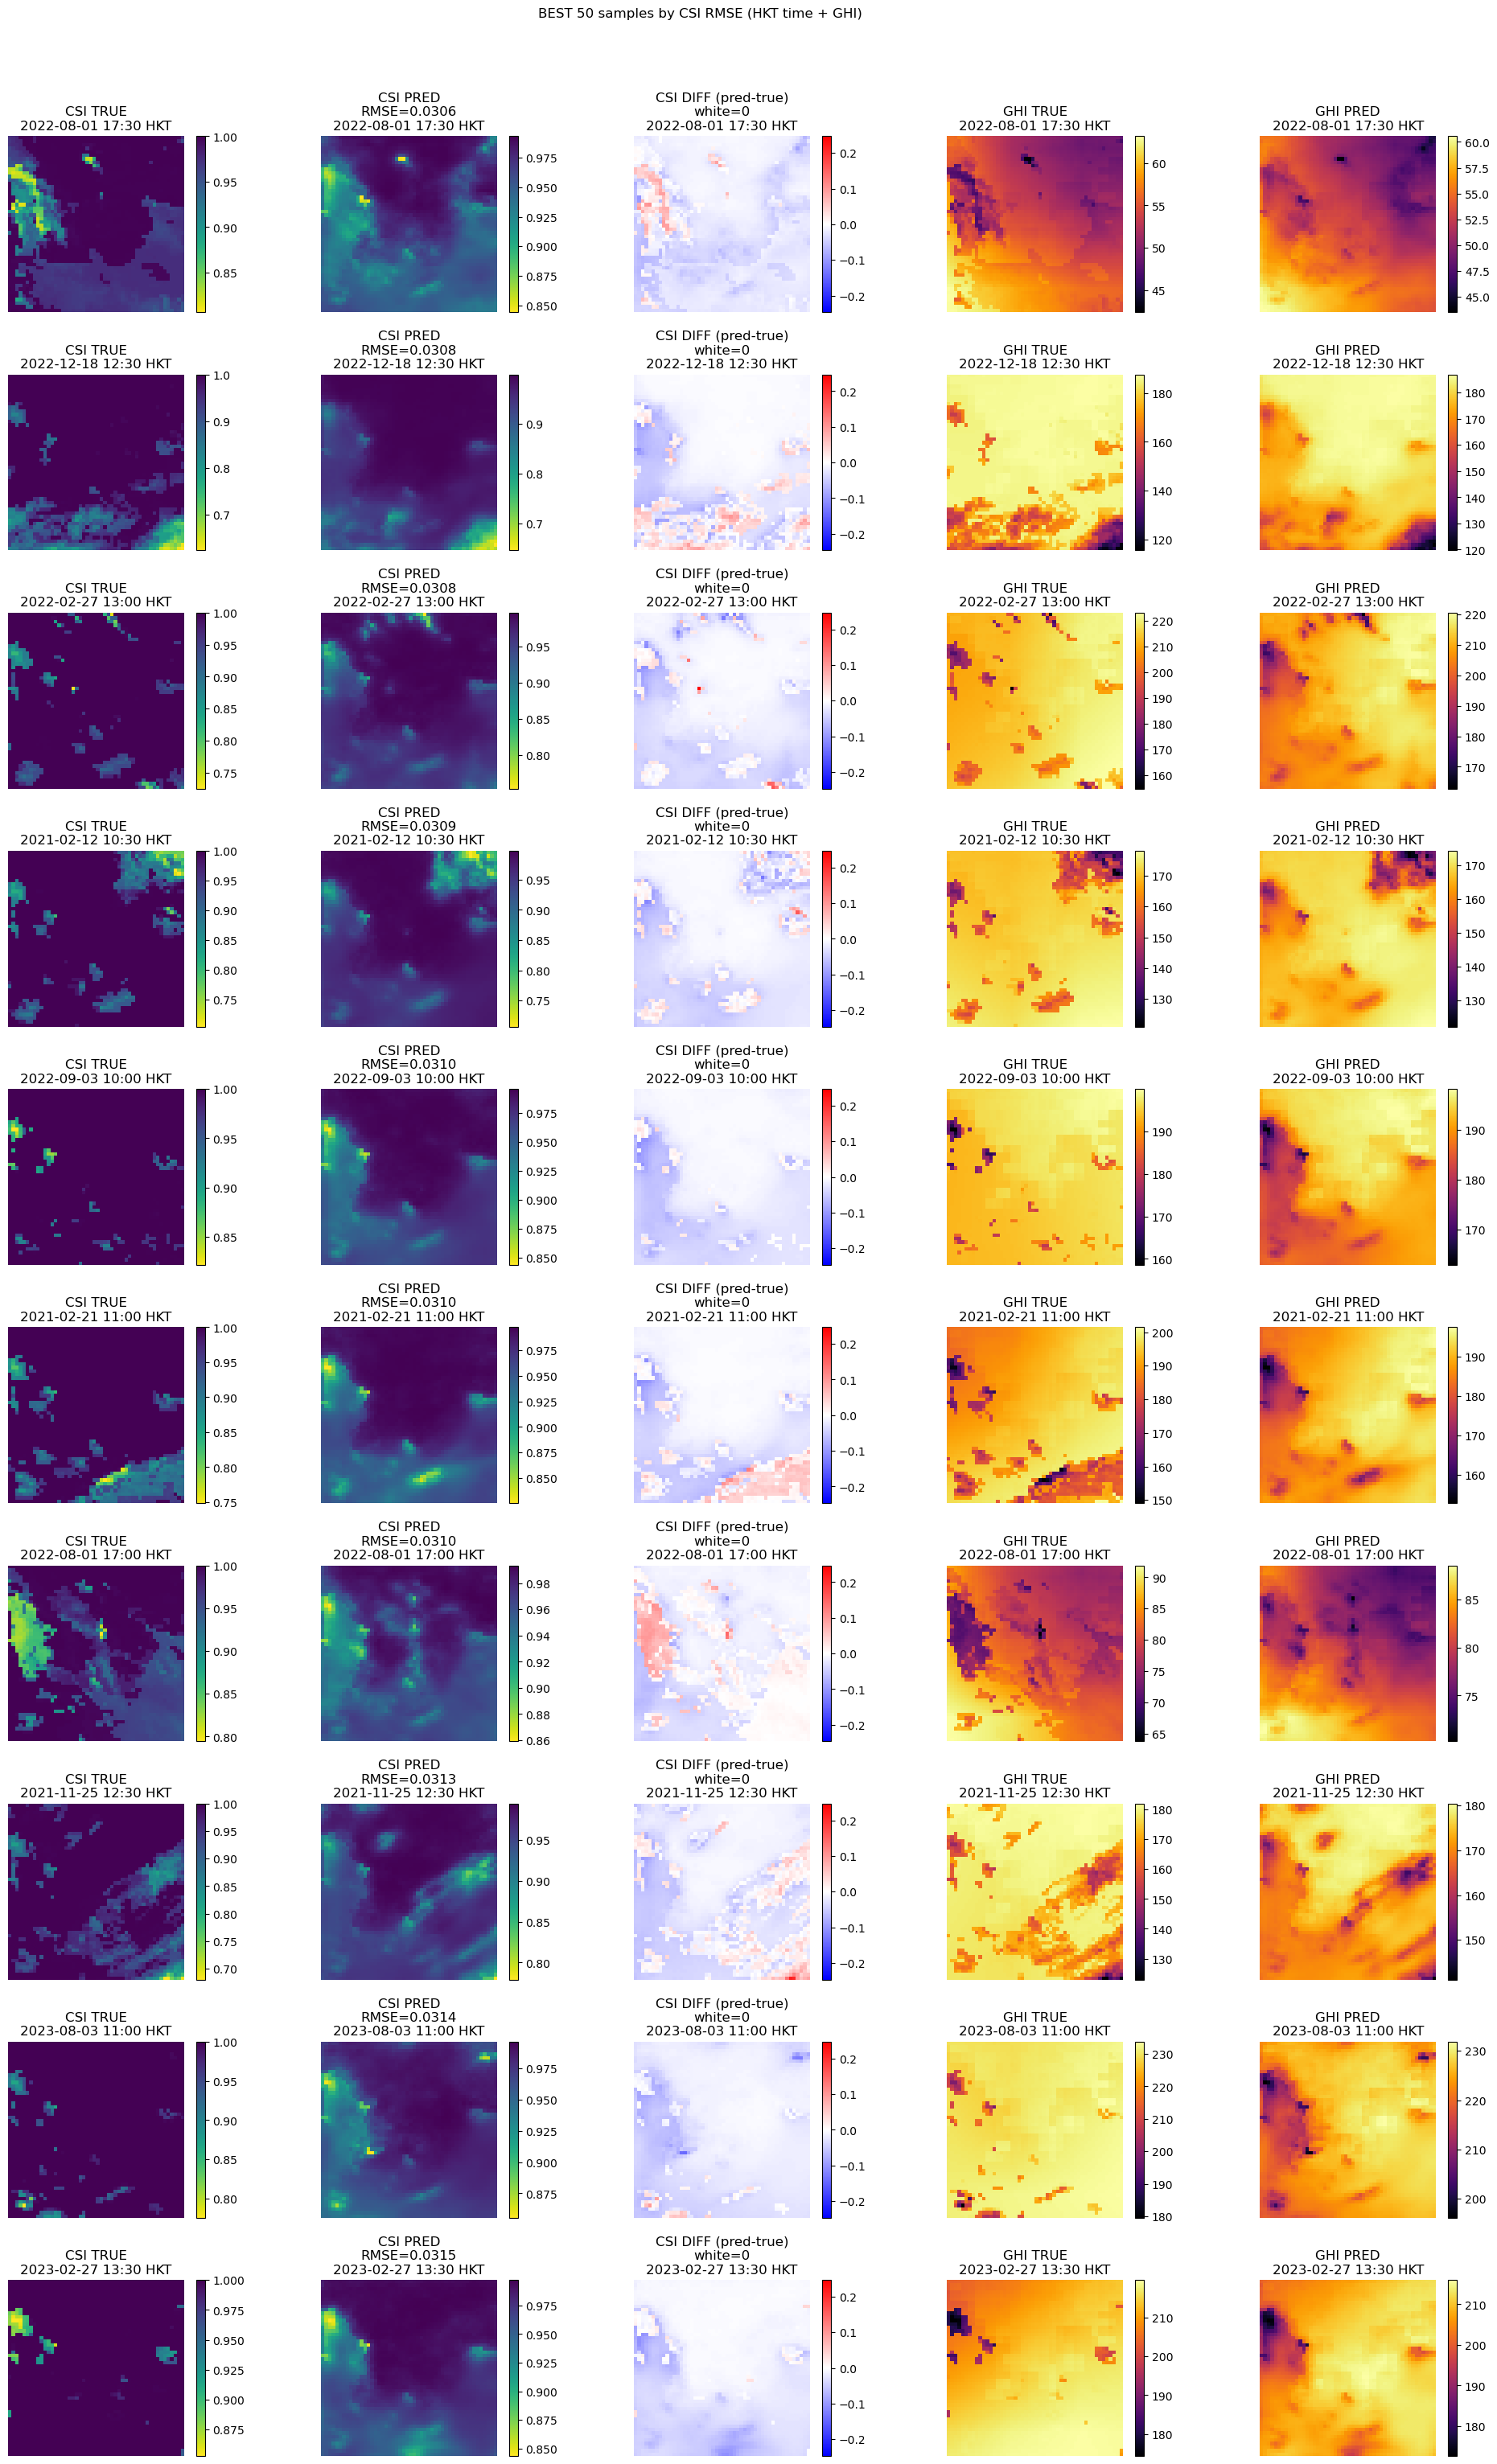

In [ ]:
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="best",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)
